<a href="https://colab.research.google.com/github/Arjun-08/Linear-Prediction-and-LPC-Analysis/blob/main/Autocorrelation_LD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal import lfilter
import scipy.linalg

Loading audio file: /content/Train_0_Example_1.wav



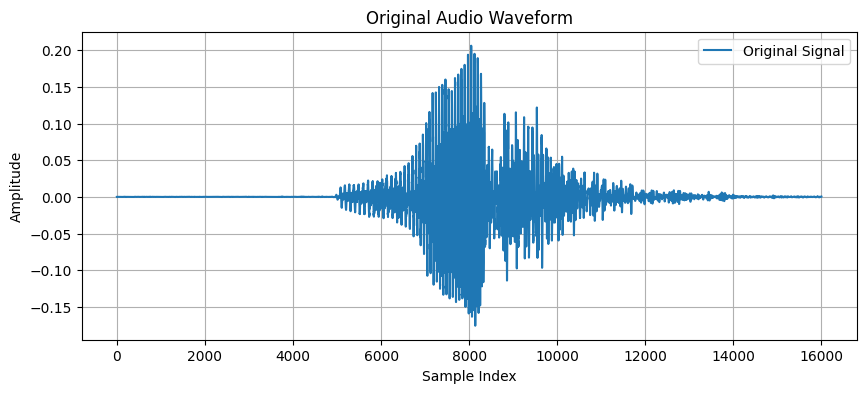


Processing for N=5

LPC Coefficients for N=5: [ 1.         -1.2747833   0.02351156  0.25724902 -0.06778535  0.12393362]

Mean Squared Error for N=5: 2.3122696806207264e-05



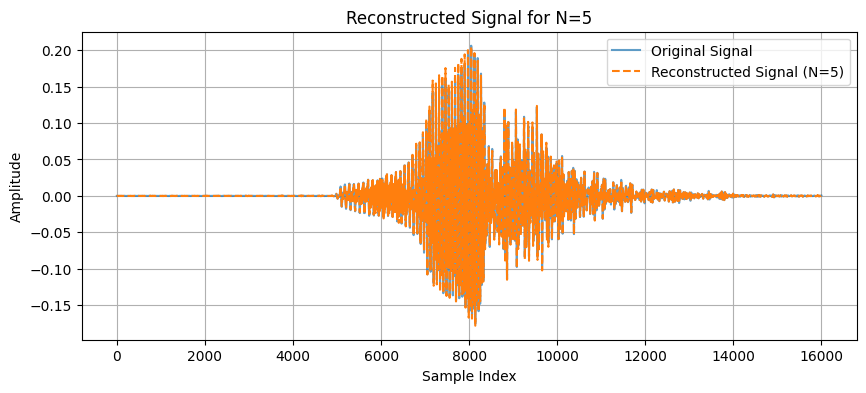

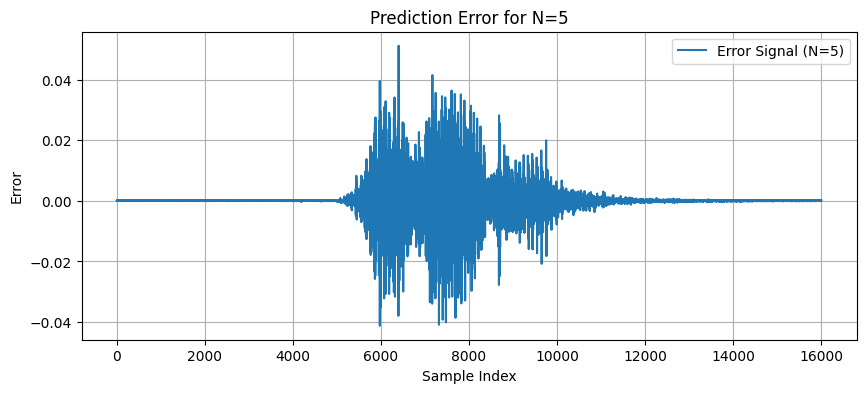


Processing for N=10

LPC Coefficients for N=10: [ 1.         -1.16801351 -0.02167157  0.2526618   0.00241519  0.01455249
 -0.13885196  0.01497161  0.06297817  0.07735635  0.01743444]

Mean Squared Error for N=10: 2.060842717301354e-05



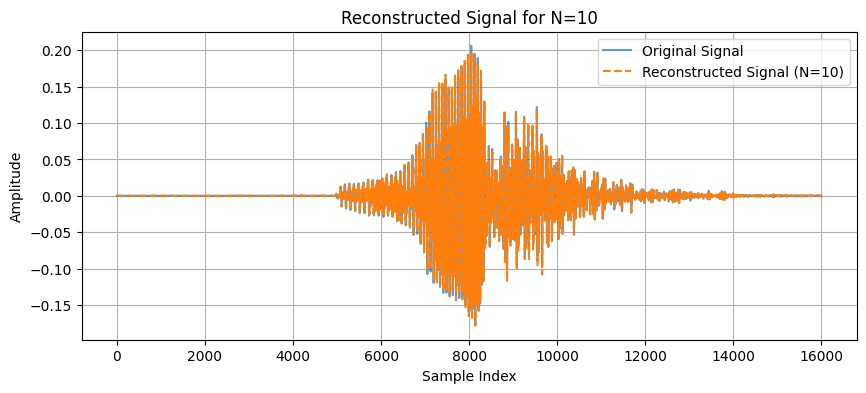

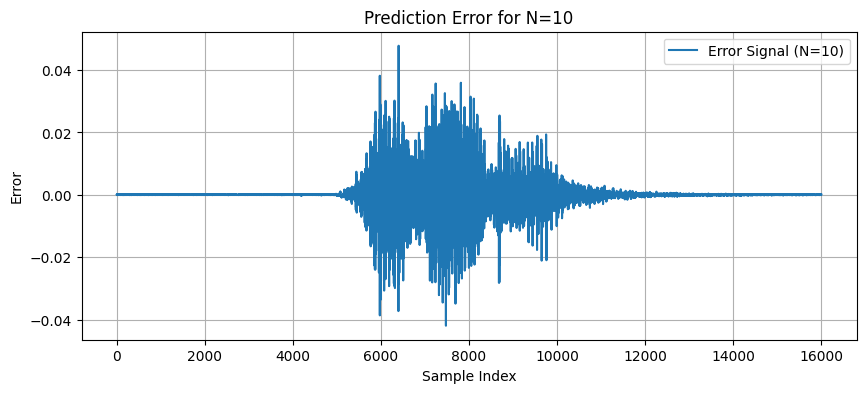


Processing for N=20

LPC Coefficients for N=20: [ 1.         -1.24674064  0.2133404   0.01763214  0.11069979  0.02343625
 -0.19564357  0.04762961  0.00962045  0.18092464 -0.20324863  0.10061156
 -0.0217334  -0.12775627  0.53903842 -0.40603081  0.29573994 -0.41209714
  0.23804212 -0.05119803 -0.01763131]

Mean Squared Error for N=20: 1.5028988645095041e-05



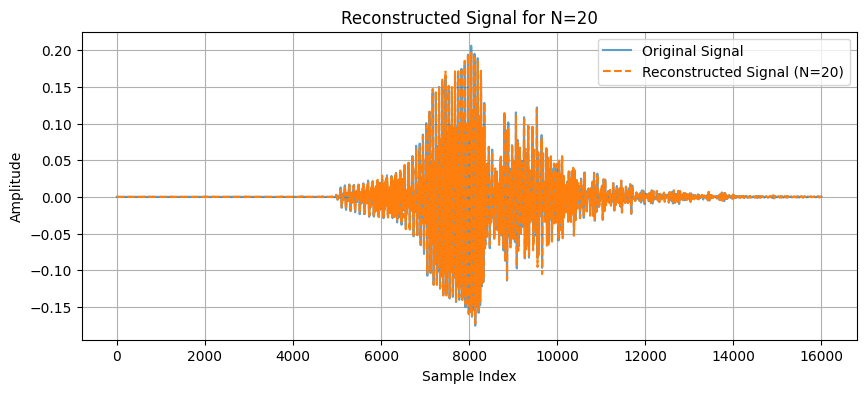

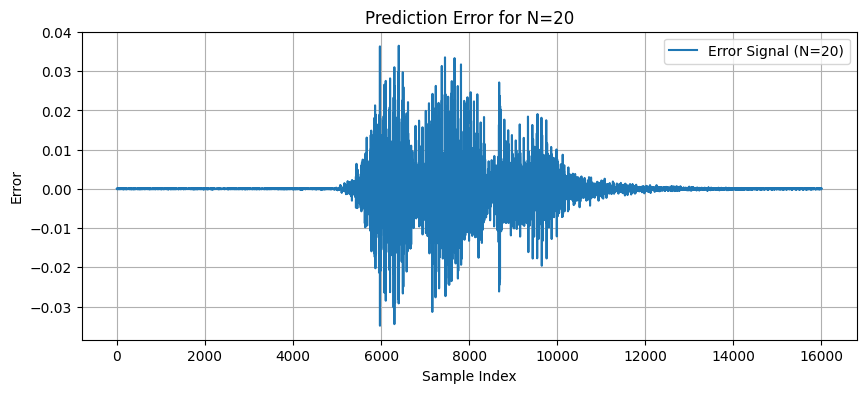

In [ ]:
file_path = "/content/Train_0_Example_1.wav"
N_values = [5, 10, 20]  # Different values of N

print(f"Loading audio file: {file_path}\n")
x, sr = librosa.load(file_path, sr=None, duration=1.0)

plt.figure(figsize=(10, 4)) ##plot for original signal
plt.plot(x, label='Original Signal')
plt.title("Original Audio Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

errors = {}
reconstructed_signals = {}
coefficients = {}
MSE_values = {}

for N in N_values:
    print(f"\nProcessing for N={N}\n")

    R = np.correlate(x, x, mode='full')
    R = R[len(x)-1:len(x)-1+N+1]
    a = scipy.linalg.solve_toeplitz((R[:-1], R[:-1]), -R[1:])
    a = np.insert(a, 0, 1)
    coefficients[N] = a
    print(f"LPC Coefficients for N={N}: {a}\n")

    e = lfilter(a, 1, x)
    reconstructed = x - e
    errors[N] = e
    reconstructed_signals[N] = reconstructed

    MSE = np.mean(e ** 2)
    MSE_values[N] = MSE
    print(f"Mean Squared Error for N={N}: {MSE}\n")

    plt.figure(figsize=(10, 4)) ##reconstructed signal
    plt.plot(x, label='Original Signal', alpha=0.7)
    plt.plot(reconstructed, label=f'Reconstructed Signal (N={N})', linestyle='dashed')
    plt.title(f"Reconstructed Signal for N={N}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(10, 4)) ###error signal
    plt.plot(e, label=f'Error Signal (N={N})')
    plt.title(f"Prediction Error for N={N}")
    plt.xlabel("Sample Index")
    plt.ylabel("Error")
    plt.legend()
    plt.grid()
    plt.show()




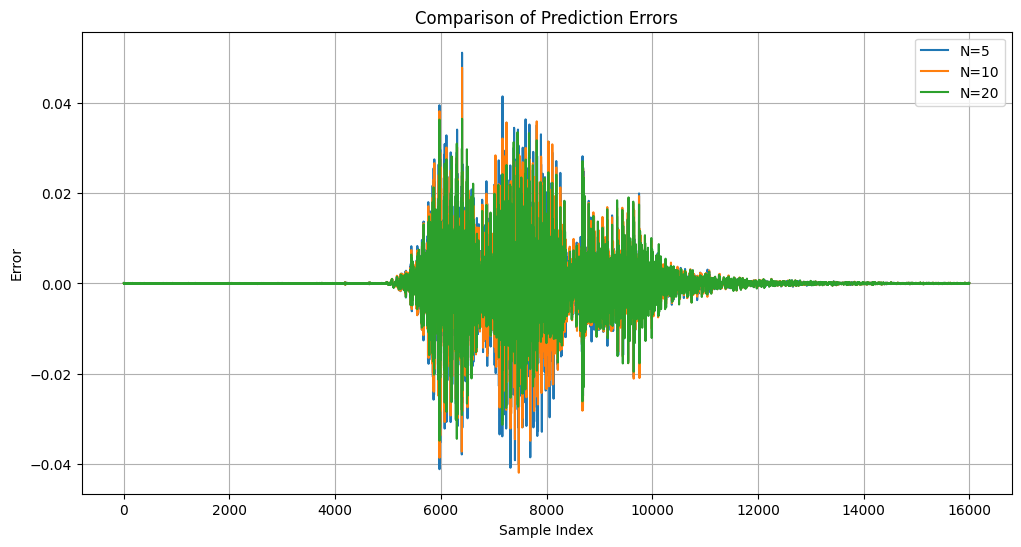

In [ ]:
plt.figure(figsize=(12, 6)) ##plot to compare prediction errors
for N in N_values:
    plt.plot(errors[N], label=f'N={N}')
plt.title("Comparison of Prediction Errors")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------------------------------

 Given coefficents for LP and MSE, find the correlation

In [ ]:
# Given LPC coefficients and MSE values for different N values
coefficients = {
    5: np.array([1, -1.2747833, 0.02351156, 0.25724902, -0.06778535, 0.12393362]),
    10: np.array([1, -1.16801351, -0.02167157, 0.2526618, 0.00241519, 0.01455249,
                  -0.13885196, 0.01497161, 0.06297817, 0.07735635, 0.01743444]),
    20: np.array([1, -1.24674064, 0.2133404, 0.01763214, 0.11069979, 0.02343625,
                  -0.19564357, 0.04762961, 0.00962045, 0.18092464, -0.20324863,
                  0.10061156, -0.0217334, -0.12775627, 0.53903842, -0.40603081,
                  0.29573994, -0.41209714, 0.23804212, -0.05119803, -0.01763131])
}

MSE_values = {
    5: 2.3122696806207264e-05,
    10: 2.060842717301354e-05,
    20: 1.5028988645095041e-05
}

def compute_autocorrelation(lp_coeffs, mse):
    p = len(lp_coeffs) - 1  # Order of LP model

    A = np.zeros((p+1, p+1))  # Toeplitz matrix
    A[0, 0] = 1
    A[1:, 0] = -lp_coeffs[1:]
    A[0, 1:] = -lp_coeffs[1:]
    for i in range(1, p+1):
        for j in range(1, p+1):
            A[i, j] = A[i-1, j-1]

    b = np.zeros(p+1)
    b[0] = mse

    R = np.linalg.solve(A, b)
    rho = R / R[0]     #normalized correlation coefficients

    return R, rho

results = {}
for N in [5, 10, 20]:
    R_values, rho_values = compute_autocorrelation(coefficients[N], MSE_values[N])
    results[N] = (R_values, rho_values)

for N, (R_values, rho_values) in results.items():
    print(f"\nAutocorrelation Results for N={N}\n" + "="*40)
    print(f"{'k':<5} {'R(k)':<20} {'rho(k)':<20}")
    print("-"*40)
    for i, (r, rho) in enumerate(zip(R_values, rho_values)):
        print(f"{i:<5} {r:<20.10f} {rho:<20.10f}")



Autocorrelation Results for N=5
k     R(k)                 rho(k)              
----------------------------------------
0     0.0000189828         1.0000000000        
1     0.0000018584         0.0979017330        
2     -0.0000164516        -0.8666574534       
3     0.0000077071         0.4060056268        
4     0.0000139100         0.7327703610        
5     -0.0000195566        -1.0302270570       

Autocorrelation Results for N=10
k     R(k)                 rho(k)              
----------------------------------------
0     0.0000229588         1.0000000000        
1     0.0000004006         0.0174470202        
2     -0.0000223137        -0.9719007657       
3     0.0000146795         0.6393836505        
4     0.0000172921         0.7531781998        
5     -0.0000267514        -1.1651913038       
6     -0.0000014685        -0.0639631800       
7     0.0000243747         1.0616704976        
8     -0.0000096066        -0.4184262405       
9     -0.0000182429        -0.79459

 Code LD recursion and solve it for N=10


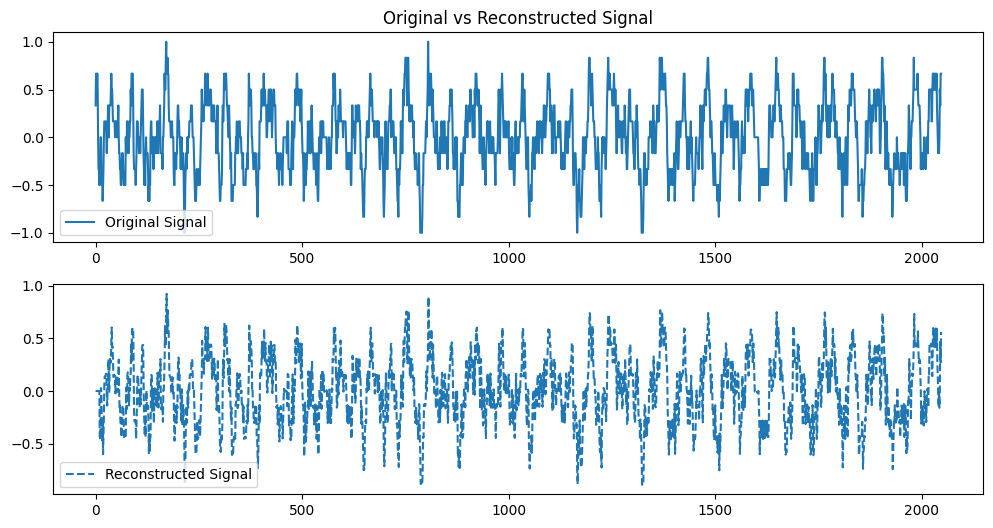

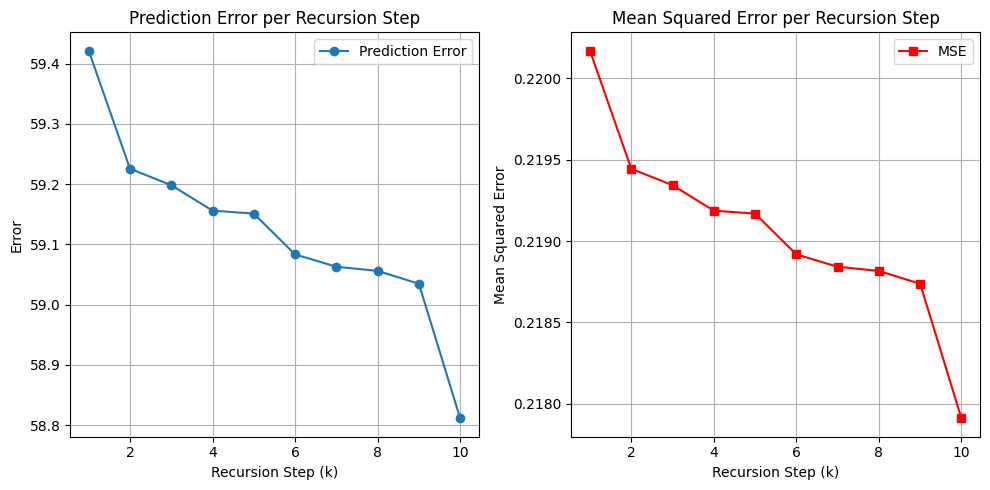

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

def compute_autocorrelation(signal, N):
    r = np.array([np.sum(signal[:len(signal)-k] * signal[k:]) for k in range(N+1)])
    return r

def levinson_durbin_manual(r, N):
    a = np.zeros(N+1)
    error = np.zeros(N+1)
    mse = np.zeros(N+1)

    a[1] = -r[1] / r[0]
    error[1] = r[0] + r[1] * a[1]
    mse[1] = error[1] / r[0]

    for k in range(2, N+1):
        lambda_k = - (r[k] + np.dot(a[1:k], r[k-1:0:-1])) / error[k-1]

        a[1:k] = a[1:k] + lambda_k * a[k-1:0:-1]
        a[k] = lambda_k

        error[k] = error[k-1] * (1 - lambda_k**2)
        mse[k] = error[k] / r[0]

    return a[1:N+1], error, mse

def reconstruct_signal(lpc_coeffs, signal, N):
    predicted = np.zeros_like(signal)
    for n in range(N, len(signal)):
        predicted[n] = -np.dot(lpc_coeffs, signal[n-N:n][::-1])
    return predicted

file_path = "/content/Train_0_Example_1.wav"
fs, audio = wav.read(file_path)

audio = audio[:,0] if len(audio.shape) > 1 else audio
segment = audio[:2048]

segment = segment / np.max(np.abs(segment))

N = 10
r = compute_autocorrelation(segment, N)  # Compute autocorrelation

lpc_coeffs, error, mse = levinson_durbin_manual(r, N) #Levinson-Durbin recursion

reconstructed = reconstruct_signal(lpc_coeffs, segment, N)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(segment, label="Original Signal")
plt.legend()
plt.title("Original vs Reconstructed Signal")
plt.subplot(2, 1, 2)
plt.plot(reconstructed, label="Reconstructed Signal", linestyle='dashed')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, N+1), error[1:], marker='o', linestyle='-', label="Prediction Error")
plt.xlabel("Recursion Step (k)")
plt.ylabel("Error")
plt.title("Prediction Error per Recursion Step")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, N+1), mse[1:], marker='s', linestyle='-', color='r', label="MSE")
plt.xlabel("Recursion Step (k)")
plt.ylabel("Mean Squared Error")
plt.title("Mean Squared Error per Recursion Step")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("LPC Coefficients:", lpc_coeffs)
print("Final MSE:", mse[-1])

LPC Coefficients: [-0.93264268  0.03566699  0.04673306 -0.01558721 -0.04373484  0.05132482
 -0.02503542 -0.00468815 -0.0384289   0.0615108 ]
Final MSE: 0.21790972387163982


Among auto correlation and covariance method which method will match LD recursion approach for N=5,10,20

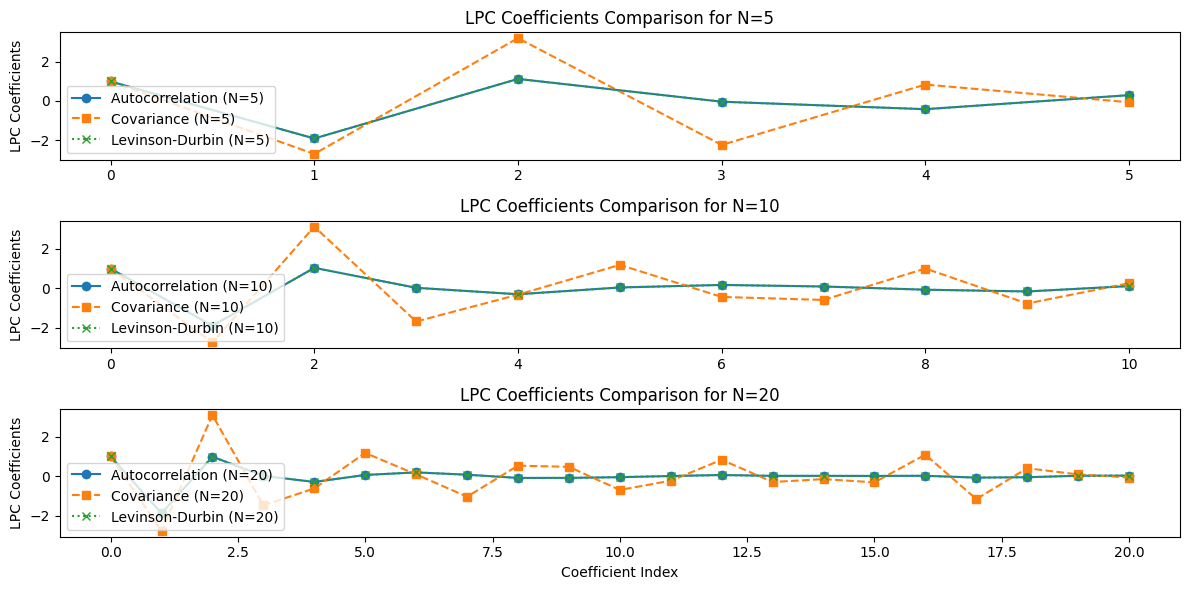


--- LPC Coefficients for N=5 ---
Autocorrelation: [ 1.         -1.92046735  1.12983421 -0.03614488 -0.41996299  0.29845855]
Covariance: [ 1.         -2.71245782  3.21809224 -2.25015577  0.84051155 -0.06517405]
Levinson-Durbin: [ 1.         -1.92046735  1.12983421 -0.03614488 -0.41996299  0.29845855]
MSE (Autocorrelation vs LD): 4.057647878645846e-26
MSE (Covariance vs LD): 1.935156586786455

--- LPC Coefficients for N=10 ---
Autocorrelation: [ 1.         -1.89939227  1.03740613  0.02618132 -0.30117918  0.0423576
  0.17097688  0.09162836 -0.07036924 -0.15977607  0.1129864 ]
Covariance: [ 1.         -2.74557949  3.12941541 -1.6831188  -0.32306083  1.18837574
 -0.43719666 -0.58948821  1.00375496 -0.77153736  0.25994398]
Levinson-Durbin: [ 1.         -1.89939227  1.03740613  0.02618132 -0.30117918  0.0423576
  0.17097688  0.09162836 -0.07036924 -0.15977607  0.1129864 ]
MSE (Autocorrelation vs LD): 1.2531105610516802e-26
MSE (Covariance vs LD): 1.064678637241711

--- LPC Coefficients for N

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.linalg

def autocorrelation_method(signal, order):  #autocorrelation method
    R = np.correlate(signal, signal, mode='full')[len(signal)-1:len(signal)-1+order+1]
    R_matrix = scipy.linalg.toeplitz(R[:-1])
    r_vector = R[1:]
    lpc_coeffs = np.linalg.solve(R_matrix, r_vector)
    return np.concatenate(([1], -lpc_coeffs))

def covariance_method(signal, order): #covariance method
    N = len(signal)
    R_matrix = np.zeros((order, order))
    r_vector = np.zeros(order)

    for i in range(order):
        for j in range(order):
            R_matrix[i, j] = np.sum(signal[i:N-order+i] * signal[j:N-order+j])
        r_vector[i] = np.sum(signal[i+1:N-order+i+1] * signal[:N-order])

    lpc_coeffs = np.linalg.solve(R_matrix, r_vector)
    return np.concatenate(([1], -lpc_coeffs))

def levinson_durbin(R, order):  #Levinson-Durbin recursion
    a = np.zeros(order+1)
    a[0] = 1
    E = R[0]

    for k in range(1, order+1):
        lambda_k = -np.dot(R[1:k+1], a[k-1::-1]) / E
        a[1:k+1] += lambda_k * a[k-1::-1]
        E *= (1 - lambda_k**2)

    return a

filename = "/content/Train_0_Example_1.wav"
fs, audio = wav.read(filename)

if len(audio.shape) > 1:
    audio = np.mean(audio, axis=1)

audio = audio / np.max(np.abs(audio))

segment = audio[10000:11000]

N_values = [5, 10, 20] # LPC Orders

results = {}

for N in N_values:
    R = np.correlate(segment, segment, mode='full')[len(segment)-1:len(segment)-1+N+1]
    lpc_autocorr = autocorrelation_method(segment, N)
    lpc_cov = covariance_method(segment, N)
    lpc_ld = levinson_durbin(R, N)

    mse_autocorr = np.mean((lpc_autocorr - lpc_ld) ** 2)
    mse_cov = np.mean((lpc_cov - lpc_ld) ** 2)

    results[N] = {
        "Autocorrelation Coeffs": lpc_autocorr,
        "Covariance Coeffs": lpc_cov,
        "Levinson-Durbin Coeffs": lpc_ld,
        "MSE Autocorr": mse_autocorr,
        "MSE Cov": mse_cov
    }

plt.figure(figsize=(12, 6))
for i, N in enumerate(N_values):
    plt.subplot(len(N_values), 1, i+1)
    plt.plot(results[N]["Autocorrelation Coeffs"], label=f"Autocorrelation (N={N})", marker='o')
    plt.plot(results[N]["Covariance Coeffs"], label=f"Covariance (N={N})", marker='s', linestyle='dashed')
    plt.plot(results[N]["Levinson-Durbin Coeffs"], label=f"Levinson-Durbin (N={N})", marker='x', linestyle='dotted')
    plt.ylabel("LPC Coefficients")
    plt.legend()
    plt.title(f"LPC Coefficients Comparison for N={N}")

plt.xlabel("Coefficient Index")
plt.tight_layout()
plt.show()

for N in N_values:
    print(f"\n--- LPC Coefficients for N={N} ---")
    print(f"Autocorrelation: {results[N]['Autocorrelation Coeffs']}")
    print(f"Covariance: {results[N]['Covariance Coeffs']}")
    print(f"Levinson-Durbin: {results[N]['Levinson-Durbin Coeffs']}")
    print(f"MSE (Autocorrelation vs LD): {results[N]['MSE Autocorr']}")
    print(f"MSE (Covariance vs LD): {results[N]['MSE Cov']}")
